# __Reto 8: Visualizacion de los Datos__

## Objetivo

Extraer hallazgos de los datos a traves de visualizaciones

## Tarea 1

Cargar los datos. Vamos a trabajar con el dataset "House Prediction Rent" del reto anterior

In [2]:
# librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Tarea 2

Genera boxplots para variables numericas.

__Boxplot de Rent__

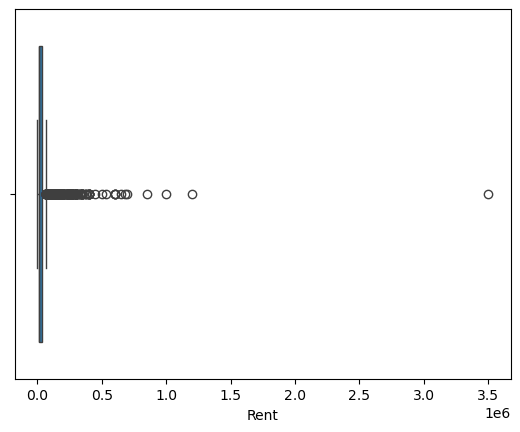

In [4]:
sns.boxplot(x=df.Rent);

> Hay rentas tan altas que escapan del comportamiento regular de la mayoria de los datos.

__Calculo del IQR para filtrar outliers__

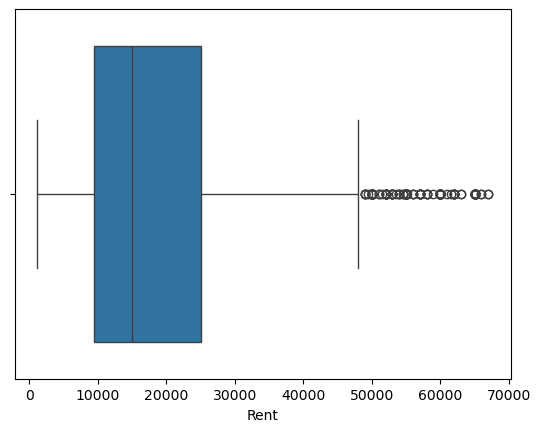

In [5]:
# Calcular cuantiles
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)

# calcular IQR
IQR = Q3 - Q1

# filtrar datos
df_filt = df[(df['Rent'] >= Q1 - 1.5*IQR) & (df['Rent'] <= Q3 + 1.5*IQR)]

# mostrar boxplot
sns.boxplot(x=df_filt['Rent']);

> El 50% de los inmuebles presenta una renta que va desde 10.000 a 25.000 aproximadamente.

> La mediana es de 15.000

__Boxplot de Size__

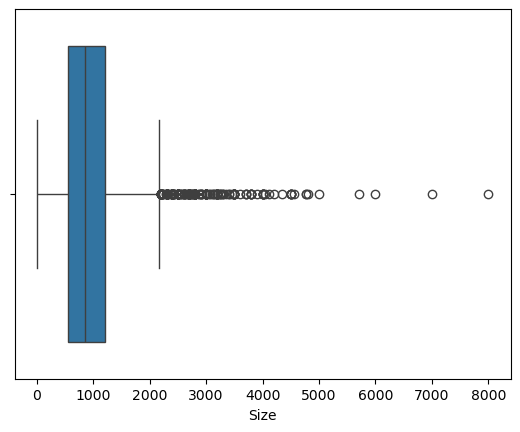

In [6]:
sns.boxplot(x=df.Size);

> Mejoremos la visualizacion del boxplot filtrando los valores extremos con IQR

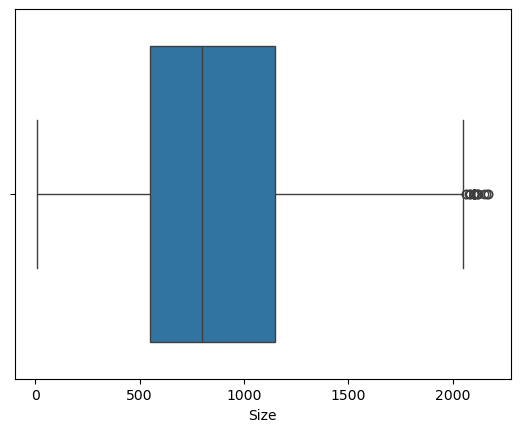

In [7]:
# Calcular cuantiles
Q1 = df['Size'].quantile(0.25)
Q3 = df['Size'].quantile(0.75)

# calcular IQR
IQR = Q3 - Q1

# filtrar datos
df_filt = df[(df['Size'] >= Q1 - 1.5*IQR) & (df['Size'] <= Q3 + 1.5*IQR)]

# mostrar boxplot
sns.boxplot(x=df_filt['Size']);

> El 50% de los inmuebles presenta un area que va desde 550 a 1200 metros cuadrados.

> La media es de aproximadamente 800 metros cuadrados.

## Tarea 3

Generar boxplot estratificado

__Boxplot de Rent basado en Area Type__

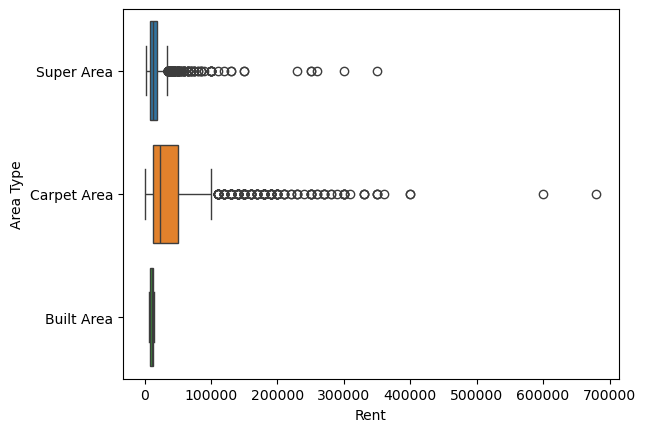

In [8]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Area Type'], hue=df_filt['Area Type']);

> Hay un mayor costo en inmuebles de tipo de area 'carpet'.

> Inmuebles de tipo 'Built' son los mas baratos.

__Boxplot de Size basado en el Area Type__

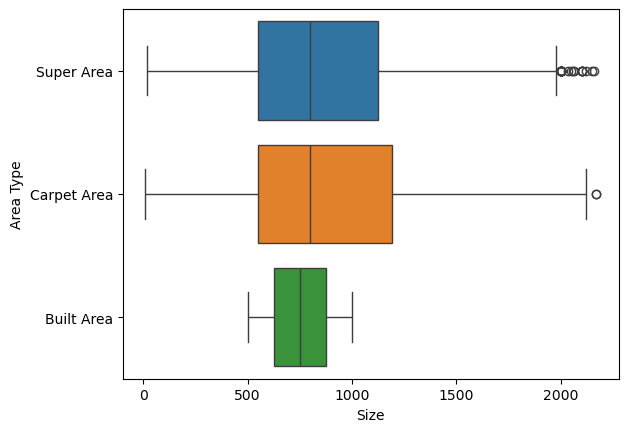

In [9]:
sns.boxplot(x=df_filt['Size'], y=df_filt['Area Type'], hue=df_filt['Area Type']);

> Super area tiende a ser mayor que el resto.

> La mayoria de inmuebles esta etre 600 y 1000 metros cuadrados.

> La variabilidad es mayor en areas Carpet que en areas construidas.

__Boxplot de Rent basado en City__

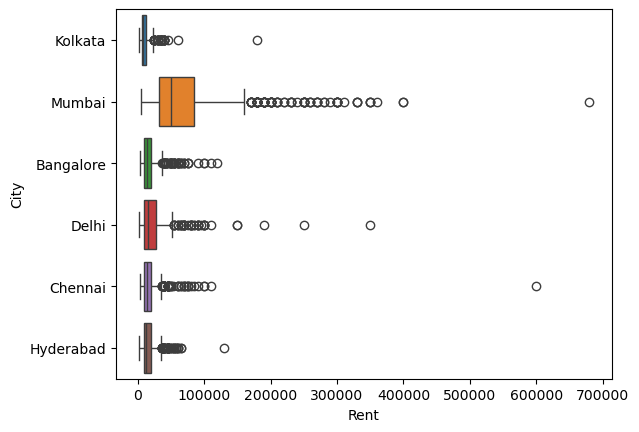

In [10]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['City'], hue=df_filt['City']);

> Usamos los datos filtrados de outliers para tener una mejor visualizacion.

> Todas las ciudades presentan asimetria positiva dado por rentas extremadamente altas.

> Mumbai es la ciudad mas cara en promedio. Presenta una alta dispersion y varios outliers extremadamente altos.

> Delhi es la segunda ciudad mas cara. Presenta una serie de outliers menos extremos.

> La presencia de outliers en todas las ciudades sugiere la presencia de propiedades de lujo.

> El mercado inmobiliario de India se encuentra altamente segmentado.

__Boxplot de Rent basado en Furnishing Status__

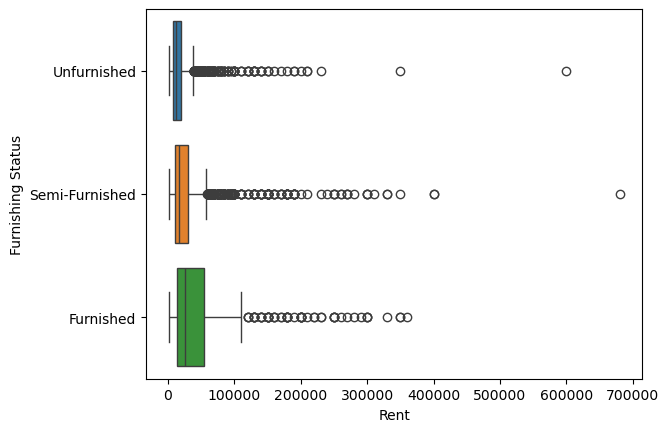

In [11]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Furnishing Status'], hue=df_filt['Furnishing Status']);

> Usamos los datos filtrados de outliers para tener una mejor visualizacion.

> Los inmuebles amueblado (Furnished) son los mas caros, en promedio. Presenta una mayor variabilidad de precio.

> Los inmuebles semi-amueblados (Semi-Furnished) se ubican en un punto medio en terminos de precio. Presentan muchos valores que siguen siendo atipicos a pesar del filtrado.

> Los inmuebles sin amueblar (Unfurnished) es la opcion mas economica y presenta una mejor variabilidad que el resto de opciones.

> Todos presentan outliers lo que sugiere propiedades muy costosas

> El nivel de amueblado si influye en el precio pero no es el unico factor determinante.

__Boxplot cruzado de Rent por City y Furnishing Status__

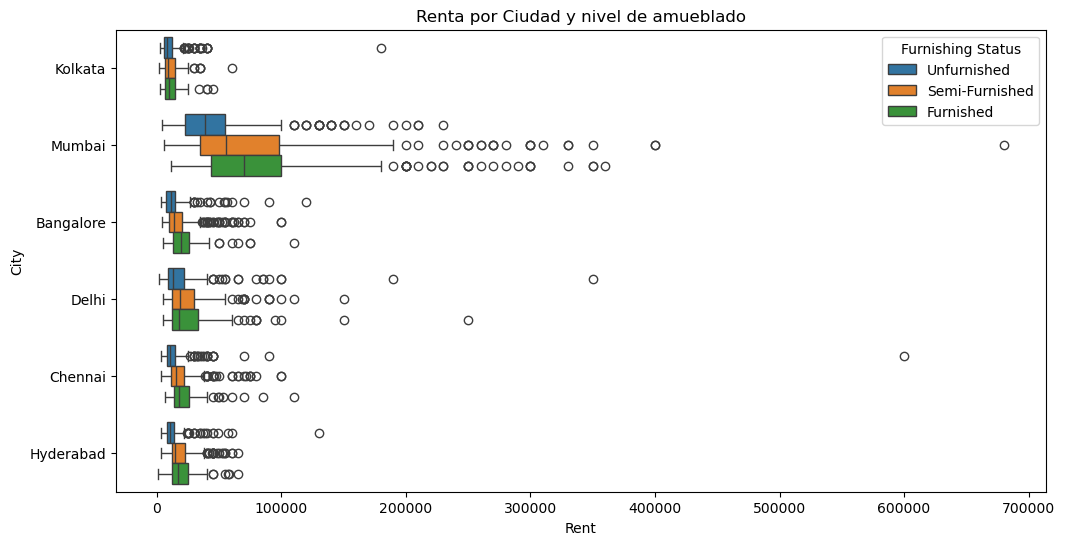

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_filt, y='City', x='Rent', hue='Furnishing Status')

plt.title('Renta por Ciudad y nivel de amueblado')
plt.show()

> En Mumbai se evidencia claramente que el amueblado si impacta fuerte en el precio.

> En ciudades como Bangalore, Chennai y Hyderabad las cajas estan muy cercanas lo que indica que el nivel de amueblado no cambia tanto el precio. Factores como ubicacion o tamano probablemente pesan mas que el amueblado.

> El amueblado agrega valor pricipalmente en mercados caros. Hay una fuerte influencia de ubicacion premium en el precio de la renta.

> Todas las ciudades presentan outliers, incluso inmuebles no amueblados lo que verifica que el precio no depende solo del amueblado.

__Boxplot de Rent basado en Tenant Preferred__

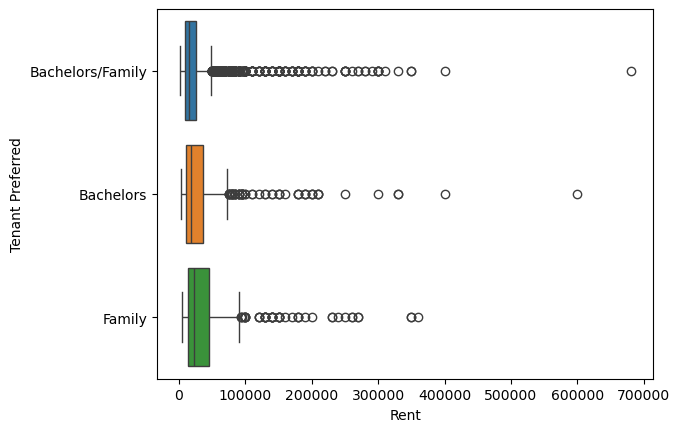

In [13]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Tenant Preferred'], hue=df_filt['Tenant Preferred']);

> Debido a que las cajas se solapan, concluimos que el tipo de inquilino preferido no es un factor fuerte para determinar el precio.

> Existen outliers en todos los segmentos lo que indica la presencia de inmuebles de alto costo que no dependen del tipo de inquilino.

> Las propiedades para familia tienden a ser mas grandes, estar mejor ubicadas y son ligeramente mas caras.

> Las propiedades mixtas, tanto para familias como para solteros, suelen estar en rangos de precios mas accesibles.

__Boxplot de Rent basado en el Point of Contact__

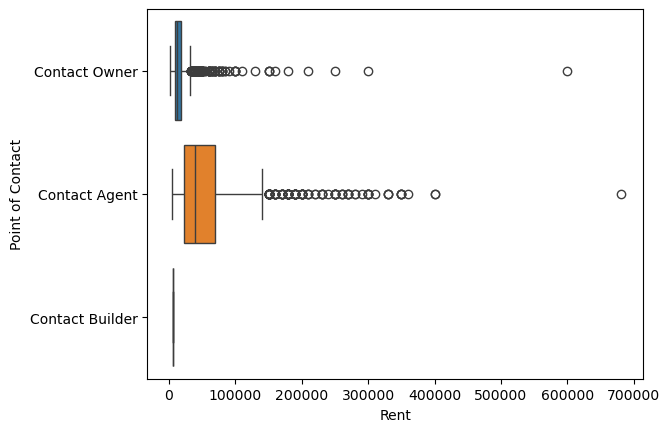

In [14]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Point of Contact'], hue=df_filt['Point of Contact']);

> 

> Los Contact Agent manejan propiedades de mayor valor.

> Del grupo Contact Builder no se pueden sacar conclusiones debido a los pocos valores muy concentrados.

> Los Contact Owner manejan las propiedades mas economicas.

__Boxplot cruzado de Rent por City y Point of Contact__

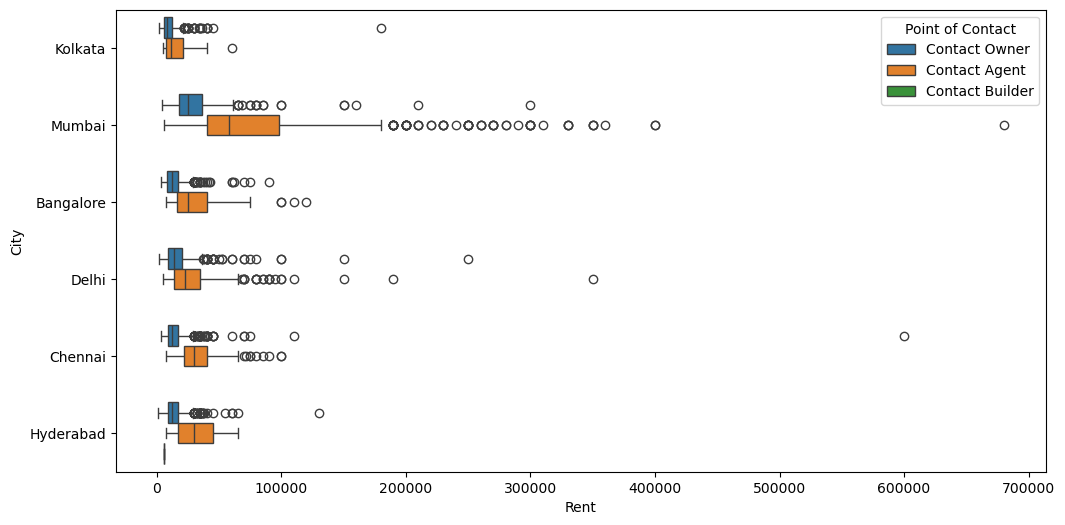

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_filt, y='City', x='Rent', hue='Point of Contact');

> Mumbai tiene la mayor variedad y valores mas altos de renta lo que indica un mercado heterogeneo.

> Kolkata y Hyderabad muestran las rentas mas bajas y concentradas.

> Arrendar directamente al propietario tiende a ser mas economico que hacerlo a traves de un agente en todas las ciudades.

## Tarea 4

Generar graficos de dispersion para mostrar la relacion entre variables.

__Scatterplot de Rent vs Size__

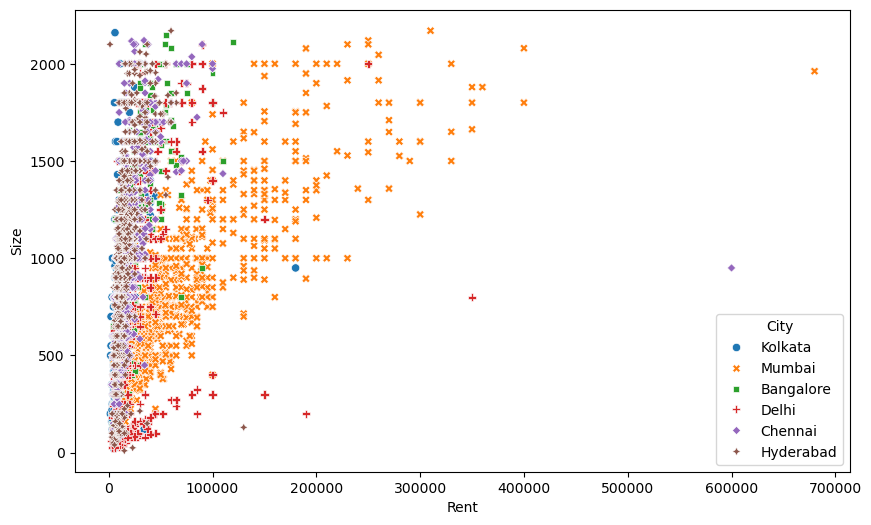

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_filt, x='Rent', y='Size', hue='City',  style='City');

> La mayoria de las ropiedades se concentra en el rango de renta que va de 0 a 100.000, independientemente del tamano.

> La correlacion es debil. Hay ciudades donde se presenta una relacion lineal, pero en general no lo es.

> Mumbai es la ciudad con propiedades costosas.

> El precio de la renta esta mas influenciado por la ciudad y otros factores que por el tamano en si.

## Tarea 5

Crear graficos de Faceting

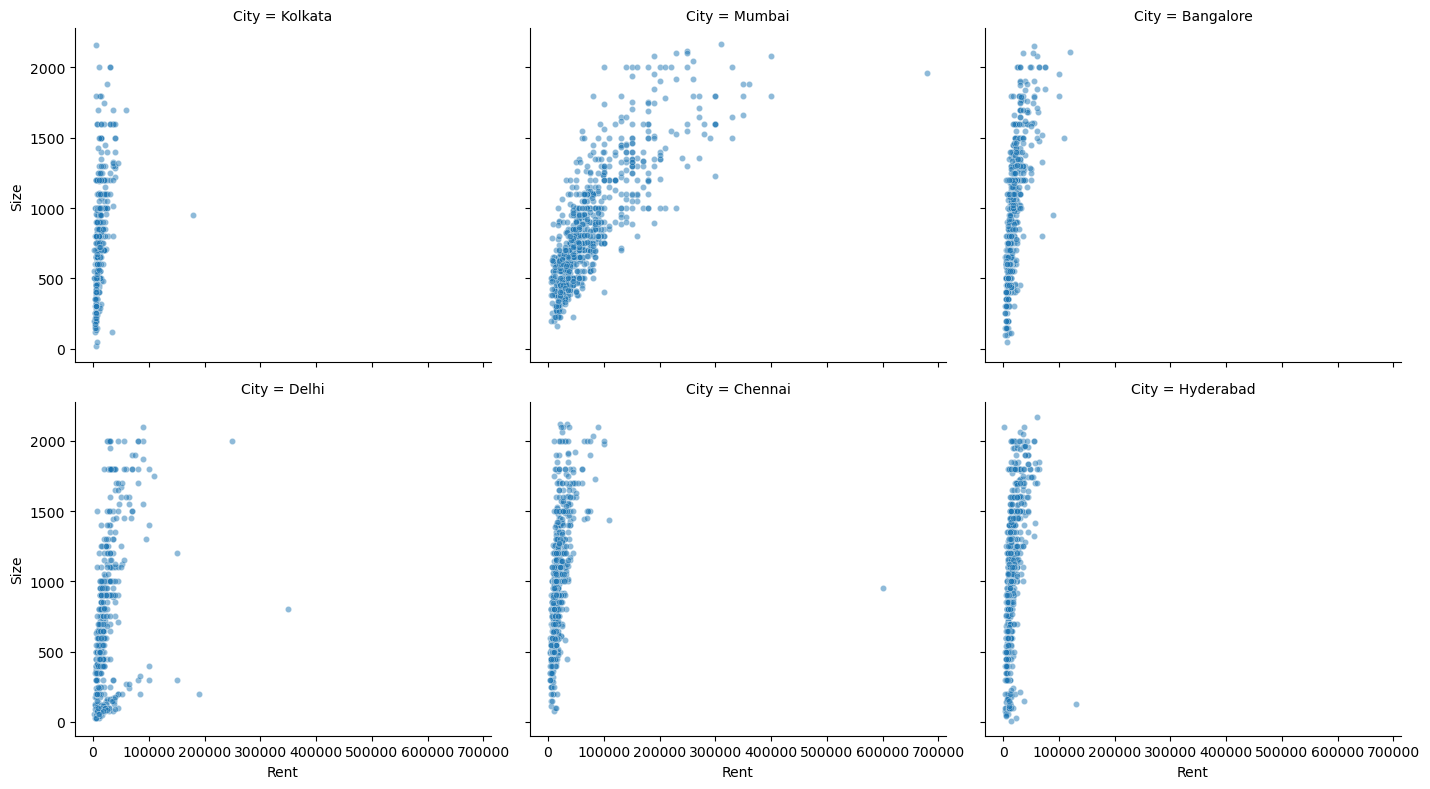

In [ ]:
sns.relplot(data=df_filt, x='Rent', y="Size", col="City", col_wrap=3, height=4, aspect=1.2, alpha=0.5, s=20)
plt.tight_layout()
plt.show()

> Mumbai es la unica ciudad donde se aprecia una correlacion positiva, a mayor tamano mayor renta. Es un mercado mas estructurado y diversificado.

> Los demas muestran propiedades de todos los tamanosa rentas muy bajas. La renta en estas propiedades no guarda relacion con el tamano.

## Tarea 6

Crear serie de tiempo

__Serie de tiempo de Rent__

In [38]:
# covertir Posted On a datetime
df_filt['Posted On'] = pd.to_datetime(df_filt['Posted On'])

# agrupar por fecha y calcular renta promedio
df_time = df_filt.groupby('Posted On')['Rent'].mean().reset_index()

/tmp/ipykernel_772/1755184141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt['Posted On'] = pd.to_datetime(df_filt['Posted On'])


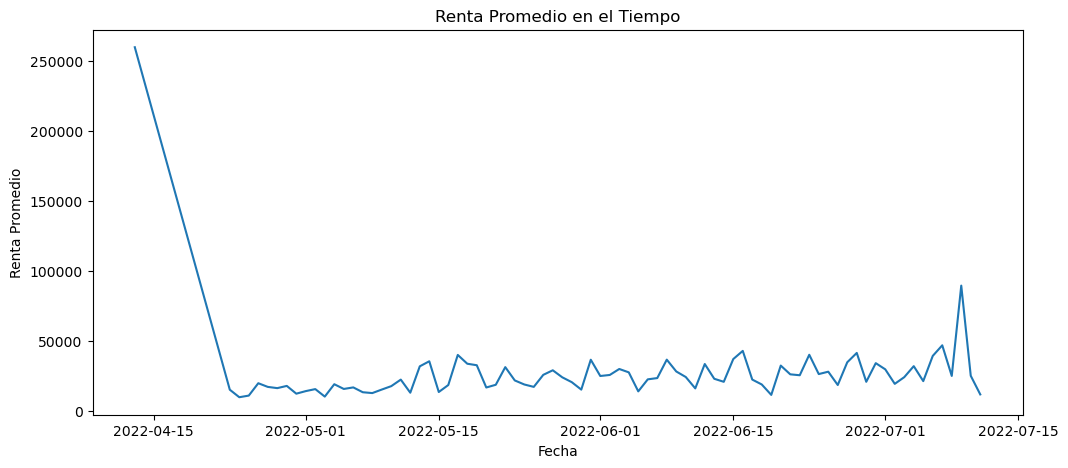

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(df_time['Posted On'], df_time['Rent'], linewidth=1.5)
plt.title('Renta Promedio en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Renta Promedio')
plt.show()

> Hay un valor extremo por el 15 de Abril lo que uede corresponder a pocas publicaciones en esas fechas. Dicho valor distorsiona el promedio.

> A partir del 1 de Mayo, la renta promedio se estabiliza entre 15.00 y 40.000.

__Serie de tiempo de Rent por Ciudad__

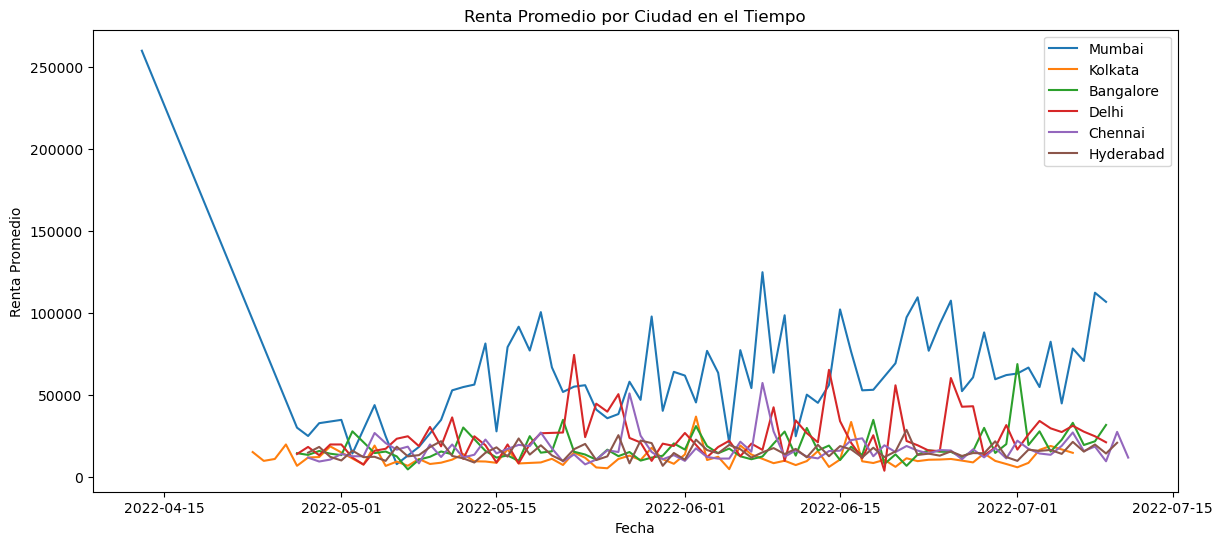

In [43]:
df_time_city = df_filt.groupby(['Posted On', 'City'])['Rent'].mean().reset_index()

plt.figure(figsize=(14, 6))
for city in df_time_city['City'].unique():
    subset = df_time_city[df_time_city['City'] == city]
    plt.plot(subset['Posted On'], subset['Rent'], label=city, linewidth=1.5)

plt.title('Renta Promedio por Ciudad en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Renta Promedio')
plt.legend()
plt.show()

> Mumbai presenta las publicaciones de valores mas altos.

> La segunda ciudad con publicaciones de propiedades con rentas altas es Delhi.